# T28 — Predicted paleolatitude from an APWP vs a `gplately` paleo-site

**Compute paleolatitude at one location through the Cenozoic two ways — from the bundled Torsvik et al. (2012) Phanerozoic global APWP (paleomagnetic reference frame) and from a `gplately` reconstruction of the same site in the Zahirovic 2022 plate model (mantle / moving-hotspot reference frame) — and compare. The gap between the two curves is a measure of true polar wander at the site over the time window.**

## What this notebook produces

A single locality — by default Cape Verde Islands (16°N, -25°E) on the African plate (701) — swept through reconstruction ages from 0 to 100 Ma. At each age we compute the paleolatitude of the site two ways:

1. **APWP** (bundled, *paleomagnetic frame*): paleolat from the great-circle distance between the site and the interpolated Torsvik et al. (2012) global APWP pole at that age. Longitudes are unwrapped before interpolation so values either side of the 0/360 cut do not produce a spurious mid-arc pole.
2. **gplately Zahirovic 2022** (*mantle / moving-hotspot frame*): paleolat from `gplately.Points.reconstruct(time, return_array=True)`. Z22 inherits the Müller 2019 absolute reference frame, which is moving-hotspot for 0–100 Ma and TPW-corrected paleomagnetic for >100 Ma.

The two paleolatitudes are plotted as a function of age. The gap between them is an estimate of *true polar wander* at the site over the time window — the rotation of the lithosphere + mantle relative to the spin axis that the mantle frame does not see but the paleomagnetic frame does. For the Cape Verde site over 0–100 Ma the integrated TPW signal is on the order of 5–10°.

The notebook also demonstrates the **longitudes-first return-order gotcha** in `Points.reconstruct(return_array=True)` — unpacking as `(rlats, rlons)` silently mis-plots the site into the wrong hemisphere.

**Audience**: postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Load a tabulated APWP and compute the predicted paleolatitude at an arbitrary site/age from the pole–site great-circle distance (`paleolat = 90 - p`), with proper longitude unwrapping.
- Use `gplately.Points.reconstruct(time, return_array=True)` to compute the paleo-position of a present-day point at the same set of ages.
- Identify which **absolute reference frame** each curve lives in (mantle/moving-hotspot vs. paleomagnetic) and read the inter-curve gap as a TPW estimate.
- Avoid the lon-first return-order gotcha.

## Prerequisites and runtime

- Plate model: Zahirovic 2022 default (0–410 Ma covers the Cenozoic).
- Python: `gplately`, `pygmt`, `numpy`, `pandas`.
- Bundled data: `data/paleomag/torsvik2012_laurentia_apwp.csv` (Phanerozoic global APWP, 701/spin-axis frame, Torsvik et al. 2012).
- Runtime: a few seconds end-to-end.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change the site + age range here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME = "Zahirovic2022"
SITE_LON, SITE_LAT = -25.0, 16.0      # Cape Verde, Africa plate (701)
PLATE_LABEL        = "Africa (plate 701)"   # human-readable label for the figure stamp
AGES = np.arange(0, 101, 5)           # Ma — sweep from 0 to 100 Ma
# ============================================================================


## 1. APWP-predicted paleolatitude at the site

We load the bundled Torsvik et al. (2012) global APWP, interpolate the pole position to each requested age (with longitudes unwrapped first), and compute the predicted paleolatitude at the site from the pole–site great-circle distance:

$$\text{paleolat} \;=\; 90^\circ - \arccos\!\bigl(\sin\phi_s\sin\phi_p + \cos\phi_s\cos\phi_p\cos(\lambda_p - \lambda_s)\bigr)$$

This APWP-derived paleolatitude is implicitly in the **paleomagnetic reference frame**: the pole is the spin-axis direction at the moment of magnetisation expressed in present-day coordinates, and the great-circle distance recovers paleolatitude directly.


In [3]:
# Cell 2 — APWP-predicted paleolatitude at the site (Torsvik 2012, paleomag frame)
# Bundled Torsvik et al. (2012) Phanerozoic global APWP in the 701 /
# spin-axis reference frame. Pole position is interpolated to each age
# (longitudes unwrapped first to avoid the 0/360 cut), then paleolat
# is computed from the pole–site great-circle distance:
#   p (deg)  = great-circle distance from site to pole
#   paleolat = 90 - p   (axial-dipole approximation)
APWP_CSV = "data/paleomag/torsvik2012_laurentia_apwp.csv"


def _paleolat_from_pole(site_lat, site_lon, pole_lat, pole_lon):
    slat, slon = np.radians(site_lat), np.radians(site_lon)
    plat, plon = np.radians(pole_lat), np.radians(pole_lon)
    cosp = (np.sin(slat) * np.sin(plat)
            + np.cos(slat) * np.cos(plat) * np.cos(plon - slon))
    return 90.0 - np.degrees(np.arccos(np.clip(cosp, -1.0, 1.0)))


apwp_table = pd.read_csv(APWP_CSV, comment="#")
apwp_age   = apwp_table["age"].values.astype(float)
apwp_plat  = apwp_table["pole_lat"].values.astype(float)
apwp_plon_unwrapped = np.degrees(np.unwrap(np.radians(
    apwp_table["pole_lon"].values.astype(float))))

torsvik_paleolats = []
for t in AGES:
    pole_lat_t = float(np.interp(float(t), apwp_age, apwp_plat))
    pole_lon_t = float(np.interp(float(t), apwp_age, apwp_plon_unwrapped)) % 360.0
    torsvik_paleolats.append(float(_paleolat_from_pole(
        SITE_LAT, SITE_LON, pole_lat_t, pole_lon_t)))
torsvik_paleolats = np.array(torsvik_paleolats)

apwp = pd.DataFrame({"age": AGES.astype(float),
                     "paleolat_torsvik": torsvik_paleolats})
apwp_label = "APWP Torsvik 2012 (paleomag frame)"
print(f"Torsvik 2012 paleolat range: "
      f"{apwp['paleolat_torsvik'].min():.2f}° to "
      f"{apwp['paleolat_torsvik'].max():.2f}°")
apwp.head()


Torsvik 2012 paleolat range: 17.45° to 39.89°


,age,paleolat_torsvik
0,0.0,17.448906
1,5.0,17.772603
2,10.0,18.042464
3,15.0,18.857045
4,20.0,19.501377


## 2. Reconstruction-predicted paleolatitude at the site

`gplately.Points.reconstruct(time, return_array=True)` returns the (lon, lat) of a present-day point reconstructed back to the requested time. **The order is longitudes first** — unpacking as `(rlats, rlons)` silently mis-plots the site into a different hemisphere. This is one of the gotchas we filed upstream as a GPlately doc clarification.

In [4]:
# Cell 3 — reconstruction-predicted paleolatitudes
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
pt = gplately.Points(recon, [SITE_LON], [SITE_LAT])

recon_paleolats = []
for t in AGES:
    rlons, rlats = pt.reconstruct(float(t), return_array=True)   # lons first!
    recon_paleolats.append(float(rlats[0]))
recon_paleolats = np.array(recon_paleolats)


## 3. Compare APWP-predicted and reconstruction-predicted paleolatitudes

The plot below shows two paleolatitude tracks:

- **Torsvik 2012 APWP** (black solid) — bundled, *paleomagnetic frame*.
- **gplately Zahirovic 2022** (red dashed) — *mantle / moving-hotspot frame* (default rotation file).

The gap between them is an estimate of *true polar wander* (TPW) at the site over the time window. Re-running with the Z22 paleomagnetic-frame rotation file (Extend this #1) would collapse the gap to within a few degrees.


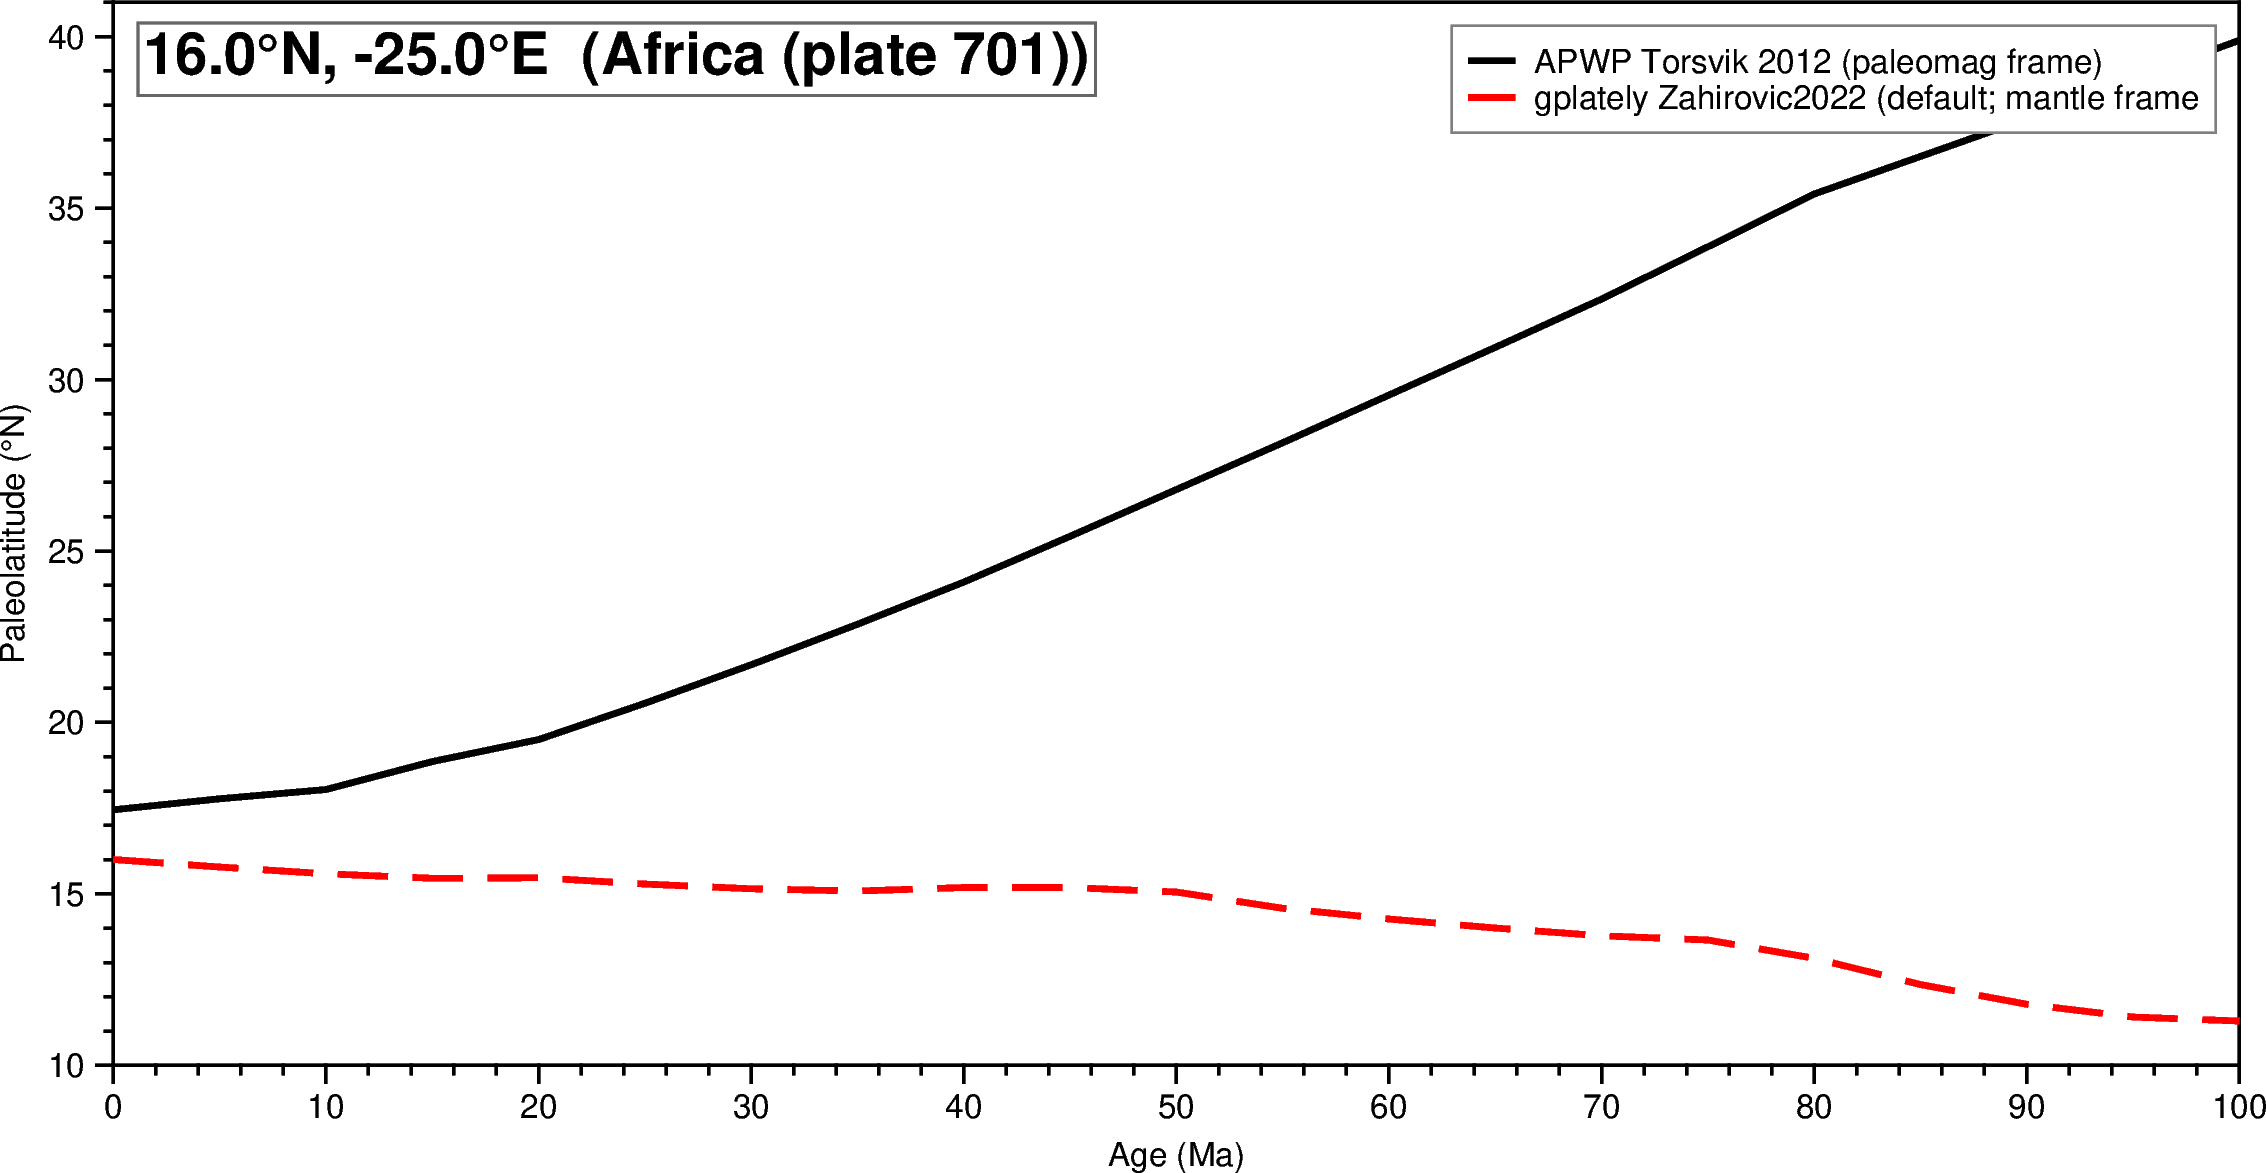

In [5]:
# Cell 4 — comparison plot
# Auto-fit the y-axis to actual data range.
combined = np.concatenate([apwp["paleolat_torsvik"].values, recon_paleolats])
combined = combined[np.isfinite(combined)]
y_lo = float(np.floor(combined.min() - 1.0))
y_hi = float(np.ceil (combined.max() + 1.0))

deg = "\260"  # GMT degree symbol (avoids backslashes inside f-strings)

fig = pygmt.Figure()
fig.basemap(region=[float(AGES.min()), float(AGES.max()), y_lo, y_hi],
            projection="X18c/9c",
            frame=["xaf+lAge (Ma)", f"yaf+lPaleolatitude ({deg}N)", "WSrt"])

# Black solid — Torsvik 2012 APWP (paleomag frame)
fig.plot(x=apwp["age"], y=apwp["paleolat_torsvik"],
         pen="1.5p,black", label=apwp_label)

# Red dashed — gplately Zahirovic 2022 default rotation (mantle / moving-
# hotspot frame for 0–100 Ma)
fig.plot(x=AGES, y=recon_paleolats,
         pen="1.5p,red,-",
         label=f"gplately {MODEL_NAME} (default; mantle frame, 0\u2013100 Ma)")

fig.legend(position="JTR+jTR+o0.2c", box="+gwhite+p0.5p,gray50")
fig.text(text=f"{SITE_LAT:.1f}{deg}N, {SITE_LON:.1f}{deg}E  ({PLATE_LABEL})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=900)
display(HTML('<div style="height:1cm"></div>'))


## What the figure shows

Two paleolatitude tracks for the Cape Verde site (16°N, 25°W), 0–100 Ma:

- **Black solid: APWP Torsvik 2012 (paleomagnetic frame).** At each age, the site's paleolatitude is computed as 90° minus the great-circle distance from the site to the interpolated Torsvik 2012 paleomagnetic pole at that age. By construction, this curve is in the spin-axis (paleomagnetic) reference frame — the only assumption is that the African plate has been rigid and that the Torsvik 2012 APWP correctly captures Africa's apparent polar wander.
- **Red dashed: gplately Zahirovic 2022, default rotation file (mantle / moving-hotspot frame).** At each age, the present-day site is reconstructed through Zahirovic 2022's rotation chain for plate 701, anchored on the spin axis (plate 0). Z22 inherits the Müller 2019 absolute frame, which is moving-hotspot for 0–100 Ma — so this curve is expressed in the *mantle* reference frame.

**What to read off the figure:**

- *Overall trend.* Both curves should show Cape Verde drifting from a lower paleolatitude in the past toward its present 16°N as Africa moves northward through the Cenozoic. The exact magnitude depends on plate model and APWP compilation but is typically 4–6° of northward latitudinal motion over 0–100 Ma.
- *Gap between the curves.* The persistent few-degree offset between the black and red lines is an estimate of *true polar wander* (TPW) at the site over the time window — the wholesale rotation of the lithosphere + mantle relative to the spin axis that the mantle frame does not see but the paleomagnetic frame does. For Cape Verde over 0–100 Ma the integrated TPW signal is on the order of 5–10°.
- *Reference-frame swap (Extend this #1).* Re-running with the Z22 paleomagnetic-frame rotation file would put both curves in the same absolute frame and collapse the gap to within a degree or two (residual = APWP-fit differences between Torsvik 2012 and what Z22 uses internally).

If the two curves cross or diverge in the wrong direction, the most common causes are the lon-first return-order gotcha in `Points.reconstruct(return_array=True)` (always unpack as `rlons, rlats = …`) and an interpolation glitch in the APWP pole longitudes (which is why we unwrap before interpolating in Cell 2).


## Extend this

- **Swap the Z22 reference frame.** Zahirovic 2022 inherits two alternative absolute reference frames from Müller 2019 — the default moving-hotspot / mantle frame and a TPW-corrected paleomagnetic frame. Pass the paleomag-frame rotation file to `gplately.PlateReconstruction(rotation_model=...)` and re-run; the red line should collapse onto the APWP.
- **Sweep latitudes.** Run the same comparison for an equatorial site and a high-latitude site. The TPW signal at the site depends on its latitude.
- **Swap plate models.** Compare `"Zahirovic2022"` vs `"Muller2022"` vs `"Merdith2021"`. The model-to-model spread bounds the APWP-fit uncertainty given the reconstruction.
- **Cross-reference T29.** T29 does the same predicted-vs-observed paleolatitude test for a single key pole at one age (the synthetic Osler 1.1 Ga pole consistent with the loaded model); this notebook does it as a function of age for one site.

## References

- Torsvik, T.H., Van der Voo, R., Preeden, U., Mac Niocaill, C., Steinberger, B., Doubrovine, P.V., van Hinsbergen, D.J.J., Domeier, M., Gaina, C., Tohver, E., Meert, J.G., McCausland, P.J.A. & Cocks, L.R.M. (2012). Phanerozoic polar wander, palaeogeography and dynamics. *Earth-Science Reviews* 114, 325–368. https://doi.org/10.1016/j.earscirev.2012.06.007
- Müller, R.D., Zahirovic, S., Williams, S.E., Cannon, J., Seton, M., Bower, D.J., Tetley, M.G., Heine, C., Le Breton, E., Liu, S., Russell, S.H.J., Yang, T., Leonard, J. & Gurnis, M. (2019). A global plate model including lithospheric deformation along major rifts and orogens since the Triassic. *Tectonics* 38, 1884–1907. https://doi.org/10.1029/2018TC005462
- Mather, B.R. et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515

- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371–383. https://doi.org/10.1002/gdj3.146
